In [35]:

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

In [36]:
df_treino = pd.read_csv('Treino_Final.csv')
pd.set_option('display.max_columns', None)
display(df_treino)

,order_id,delivery_time (days),geolocation_city_c,geolocation_state_c,payment_value,freight_value,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_city_s,geolocation_state_s,product_volume,distancia_km,purchase_to_approval_days,approval_to_carrier_days,carrier_to_customer_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.61,campos dos goytacazes,RJ,72.19,13.29,volta redonda,SP,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,RJ,3528.0,301.005664,0.032326,6.367141,1.214954
1,00018f77f2f0320c557190d7a144bdd3,16.22,santa fe do sul,SP,259.83,19.93,sao paulo,SP,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP,60000.0,589.274140,0.008414,8.145683,8.062083
2,000229ec398224ef6ca0657da4fc703e,7.95,pará de minas,MG,216.87,17.87,borda da mata,MG,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG,14157.0,312.495046,0.010405,1.908542,6.029491
3,00042b26cf59d7ce69dfabb4e55b4fd9,25.11,varzea paulista,SP,218.04,18.14,loanda,PR,ferramentas_jardim,3750.0,35.0,40.0,30.0,loanda,PR,42000.0,646.221788,0.008588,11.816620,13.289144
4,00048cc3ae777c65dbb7d2a0634bc1ea,6.67,uberaba,MG,34.59,12.69,ribeirao preto,SP,utilidades_domesticas,450.0,24.0,8.0,15.0,ribeirao preto,SP,2880.0,161.597746,1.258947,0.298935,5.110185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68319,fffb0b1a50e65c449020434fa835e078,34.79,campinas,SP,15.86,10.96,santos,SP,instrumentos_musicais,100.0,60.0,16.0,11.0,santos,SP,10560.0,146.589938,0.006586,14.695625,20.091296
68320,fffb2ef8874127f75b52b643880fd7e0,17.06,cordeiro,RJ,39.96,22.06,brusque,SC,cama_mesa_banho,200.0,25.0,5.0,18.0,brusque,SC,2250.0,876.529078,3.563704,0.419282,13.072442
68321,fffb9224b6fc7c43ebb0904318b10b5f,21.12,serra talhada,PE,356.76,34.19,sao goncalo,RJ,relogios_presentes,350.0,16.0,14.0,11.0,sao goncalo,RJ,2464.0,1725.685456,0.420116,13.691597,7.006829
68322,fffce4705a9662cd70adb13d4a31832d,4.80,sao paulo,SP,116.85,16.95,curitiba,PR,esporte_lazer,967.0,21.0,24.0,19.0,curitiba,PR,9576.0,338.827218,1.004502,1.915845,1.881343


In [37]:
df_treino.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68324 entries, 0 to 68323
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   68324 non-null  object 
 1   delivery_time (days)       68324 non-null  float64
 2   geolocation_city_c         68146 non-null  object 
 3   geolocation_state_c        68146 non-null  object 
 4   payment_value              68323 non-null  float64
 5   freight_value              67707 non-null  float64
 6   seller_city                68324 non-null  object 
 7   seller_state               68324 non-null  object 
 8   product_category_name      67128 non-null  object 
 9   product_weight_g           68308 non-null  float64
 10  product_length_cm          68308 non-null  float64
 11  product_height_cm          68308 non-null  float64
 12  product_width_cm           68308 non-null  float64
 13  geolocation_city_s         68158 non-null  obj

In [38]:
lower_limit = df_treino['delivery_time (days)'].quantile(0.01)
upper_limit = df_treino['delivery_time (days)'].quantile(0.99)

# Limitar os valores extremos (winsorização)
df_treino['delivery_time (days)'] = np.clip(df_treino['delivery_time (days)'], lower_limit, upper_limit)

# Agora o df está limpo e pronto para modelagem com XGBoost

display(df_treino)

,order_id,delivery_time (days),geolocation_city_c,geolocation_state_c,payment_value,freight_value,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_city_s,geolocation_state_s,product_volume,distancia_km,purchase_to_approval_days,approval_to_carrier_days,carrier_to_customer_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.61,campos dos goytacazes,RJ,72.19,13.29,volta redonda,SP,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,RJ,3528.0,301.005664,0.032326,6.367141,1.214954
1,00018f77f2f0320c557190d7a144bdd3,16.22,santa fe do sul,SP,259.83,19.93,sao paulo,SP,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP,60000.0,589.274140,0.008414,8.145683,8.062083
2,000229ec398224ef6ca0657da4fc703e,7.95,pará de minas,MG,216.87,17.87,borda da mata,MG,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG,14157.0,312.495046,0.010405,1.908542,6.029491
3,00042b26cf59d7ce69dfabb4e55b4fd9,25.11,varzea paulista,SP,218.04,18.14,loanda,PR,ferramentas_jardim,3750.0,35.0,40.0,30.0,loanda,PR,42000.0,646.221788,0.008588,11.816620,13.289144
4,00048cc3ae777c65dbb7d2a0634bc1ea,6.67,uberaba,MG,34.59,12.69,ribeirao preto,SP,utilidades_domesticas,450.0,24.0,8.0,15.0,ribeirao preto,SP,2880.0,161.597746,1.258947,0.298935,5.110185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68319,fffb0b1a50e65c449020434fa835e078,34.79,campinas,SP,15.86,10.96,santos,SP,instrumentos_musicais,100.0,60.0,16.0,11.0,santos,SP,10560.0,146.589938,0.006586,14.695625,20.091296
68320,fffb2ef8874127f75b52b643880fd7e0,17.06,cordeiro,RJ,39.96,22.06,brusque,SC,cama_mesa_banho,200.0,25.0,5.0,18.0,brusque,SC,2250.0,876.529078,3.563704,0.419282,13.072442
68321,fffb9224b6fc7c43ebb0904318b10b5f,21.12,serra talhada,PE,356.76,34.19,sao goncalo,RJ,relogios_presentes,350.0,16.0,14.0,11.0,sao goncalo,RJ,2464.0,1725.685456,0.420116,13.691597,7.006829
68322,fffce4705a9662cd70adb13d4a31832d,4.80,sao paulo,SP,116.85,16.95,curitiba,PR,esporte_lazer,967.0,21.0,24.0,19.0,curitiba,PR,9576.0,338.827218,1.004502,1.915845,1.881343


In [39]:
#Transformação logarítmica (somente se todos os valores forem positivos)
df_log = pd.read_csv('Treino_Final.csv')
df_log['delivery_time_log'] = np.log1p(df_log['delivery_time (days)'])
display(df_log)

,order_id,delivery_time (days),geolocation_city_c,geolocation_state_c,payment_value,freight_value,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_city_s,geolocation_state_s,product_volume,distancia_km,purchase_to_approval_days,approval_to_carrier_days,carrier_to_customer_days,delivery_time_log
0,00010242fe8c5a6d1ba2dd792cb16214,7.61,campos dos goytacazes,RJ,72.19,13.29,volta redonda,SP,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,RJ,3528.0,301.005664,0.032326,6.367141,1.214954,2.152924
1,00018f77f2f0320c557190d7a144bdd3,16.22,santa fe do sul,SP,259.83,19.93,sao paulo,SP,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP,60000.0,589.274140,0.008414,8.145683,8.062083,2.846071
2,000229ec398224ef6ca0657da4fc703e,7.95,pará de minas,MG,216.87,17.87,borda da mata,MG,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG,14157.0,312.495046,0.010405,1.908542,6.029491,2.191654
3,00042b26cf59d7ce69dfabb4e55b4fd9,25.11,varzea paulista,SP,218.04,18.14,loanda,PR,ferramentas_jardim,3750.0,35.0,40.0,30.0,loanda,PR,42000.0,646.221788,0.008588,11.816620,13.289144,3.262318
4,00048cc3ae777c65dbb7d2a0634bc1ea,6.67,uberaba,MG,34.59,12.69,ribeirao preto,SP,utilidades_domesticas,450.0,24.0,8.0,15.0,ribeirao preto,SP,2880.0,161.597746,1.258947,0.298935,5.110185,2.037317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68319,fffb0b1a50e65c449020434fa835e078,34.79,campinas,SP,15.86,10.96,santos,SP,instrumentos_musicais,100.0,60.0,16.0,11.0,santos,SP,10560.0,146.589938,0.006586,14.695625,20.091296,3.577669
68320,fffb2ef8874127f75b52b643880fd7e0,17.06,cordeiro,RJ,39.96,22.06,brusque,SC,cama_mesa_banho,200.0,25.0,5.0,18.0,brusque,SC,2250.0,876.529078,3.563704,0.419282,13.072442,2.893700
68321,fffb9224b6fc7c43ebb0904318b10b5f,21.12,serra talhada,PE,356.76,34.19,sao goncalo,RJ,relogios_presentes,350.0,16.0,14.0,11.0,sao goncalo,RJ,2464.0,1725.685456,0.420116,13.691597,7.006829,3.096482
68322,fffce4705a9662cd70adb13d4a31832d,4.80,sao paulo,SP,116.85,16.95,curitiba,PR,esporte_lazer,967.0,21.0,24.0,19.0,curitiba,PR,9576.0,338.827218,1.004502,1.915845,1.881343,1.757858


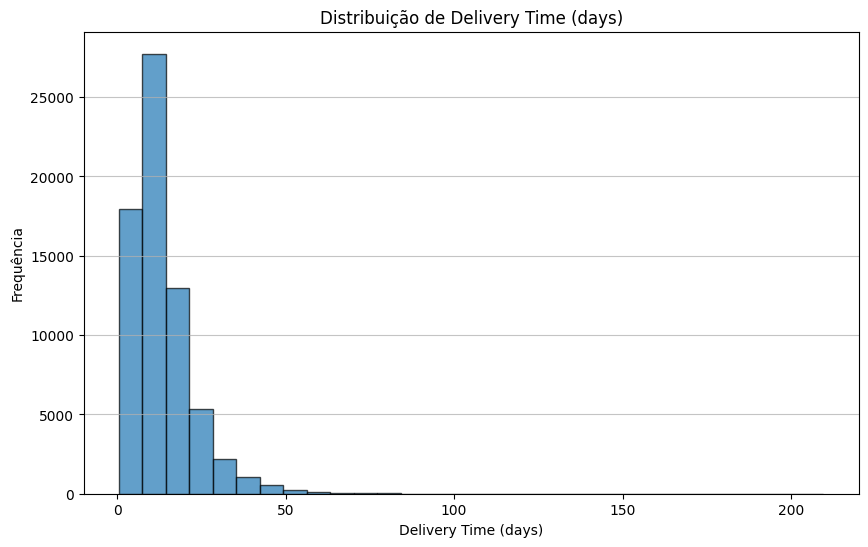

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(df_log['delivery_time (days)'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribuição de Delivery Time (days)')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

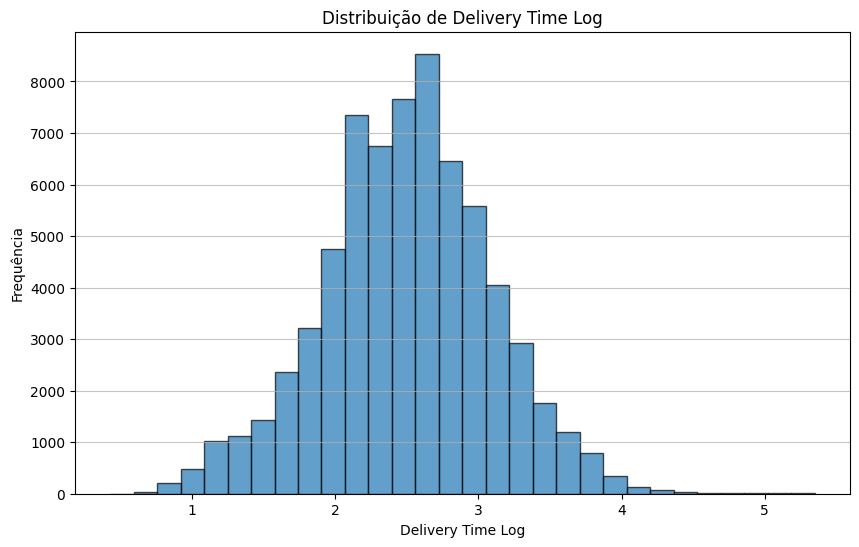

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(df_log['delivery_time_log'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribuição de Delivery Time Log')
plt.xlabel('Delivery Time Log')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [42]:
df_log.to_csv('treino_log.csv', index=False)

In [60]:
df_out = df_treino
Q1 = df_out['delivery_time (days)'].quantile(0.25)
Q3 = df_out['delivery_time (days)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 0.85 * IQR
upper_bound = Q3 + 0.85 * IQR

# Filtrar os dados para remover outliers
df_out = df_out[(df_out['delivery_time (days)'] >= lower_bound) & (df_out['delivery_time (days)'] <= upper_bound)]
display(df_out)
df_out.to_csv('treino_out_deliverytime.csv', index=False)

,order_id,delivery_time (days),geolocation_city_c,geolocation_state_c,payment_value,freight_value,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_city_s,geolocation_state_s,product_volume,distancia_km,purchase_to_approval_days,approval_to_carrier_days,carrier_to_customer_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.61,campos dos goytacazes,RJ,72.19,13.29,volta redonda,SP,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,RJ,3528.0,301.005664,0.032326,6.367141,1.214954
1,00018f77f2f0320c557190d7a144bdd3,16.22,santa fe do sul,SP,259.83,19.93,sao paulo,SP,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP,60000.0,589.274140,0.008414,8.145683,8.062083
2,000229ec398224ef6ca0657da4fc703e,7.95,pará de minas,MG,216.87,17.87,borda da mata,MG,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG,14157.0,312.495046,0.010405,1.908542,6.029491
4,00048cc3ae777c65dbb7d2a0634bc1ea,6.67,uberaba,MG,34.59,12.69,ribeirao preto,SP,utilidades_domesticas,450.0,24.0,8.0,15.0,ribeirao preto,SP,2880.0,161.597746,1.258947,0.298935,5.110185
5,00054e8431b9d7675808bcb819fb4a32,8.42,guararapes,SP,31.75,11.85,sao paulo,SP,telefonia,200.0,27.0,5.0,20.0,sao paulo,SP,2700.0,484.118172,0.011609,1.539780,6.872106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68318,fffa82886406ccf10c7b4e35c4ff2788,21.08,tenente ananias,RN,273.92,44.02,pirituba,SP,esporte_lazer,2700.0,60.0,15.0,15.0,sao paulo,SP,13500.0,2102.634123,0.041632,2.056898,18.977894
68320,fffb2ef8874127f75b52b643880fd7e0,17.06,cordeiro,RJ,39.96,22.06,brusque,SC,cama_mesa_banho,200.0,25.0,5.0,18.0,brusque,SC,2250.0,876.529078,3.563704,0.419282,13.072442
68321,fffb9224b6fc7c43ebb0904318b10b5f,21.12,serra talhada,PE,356.76,34.19,sao goncalo,RJ,relogios_presentes,350.0,16.0,14.0,11.0,sao goncalo,RJ,2464.0,1725.685456,0.420116,13.691597,7.006829
68322,fffce4705a9662cd70adb13d4a31832d,4.80,sao paulo,SP,116.85,16.95,curitiba,PR,esporte_lazer,967.0,21.0,24.0,19.0,curitiba,PR,9576.0,338.827218,1.004502,1.915845,1.881343


In [44]:
display(df_treino)

,order_id,delivery_time (days),geolocation_city_c,geolocation_state_c,payment_value,freight_value,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_city_s,geolocation_state_s,product_volume,distancia_km,purchase_to_approval_days,approval_to_carrier_days,carrier_to_customer_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.61,campos dos goytacazes,RJ,72.19,13.29,volta redonda,SP,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,RJ,3528.0,301.005664,0.032326,6.367141,1.214954
1,00018f77f2f0320c557190d7a144bdd3,16.22,santa fe do sul,SP,259.83,19.93,sao paulo,SP,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP,60000.0,589.274140,0.008414,8.145683,8.062083
2,000229ec398224ef6ca0657da4fc703e,7.95,pará de minas,MG,216.87,17.87,borda da mata,MG,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG,14157.0,312.495046,0.010405,1.908542,6.029491
3,00042b26cf59d7ce69dfabb4e55b4fd9,25.11,varzea paulista,SP,218.04,18.14,loanda,PR,ferramentas_jardim,3750.0,35.0,40.0,30.0,loanda,PR,42000.0,646.221788,0.008588,11.816620,13.289144
4,00048cc3ae777c65dbb7d2a0634bc1ea,6.67,uberaba,MG,34.59,12.69,ribeirao preto,SP,utilidades_domesticas,450.0,24.0,8.0,15.0,ribeirao preto,SP,2880.0,161.597746,1.258947,0.298935,5.110185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68319,fffb0b1a50e65c449020434fa835e078,34.79,campinas,SP,15.86,10.96,santos,SP,instrumentos_musicais,100.0,60.0,16.0,11.0,santos,SP,10560.0,146.589938,0.006586,14.695625,20.091296
68320,fffb2ef8874127f75b52b643880fd7e0,17.06,cordeiro,RJ,39.96,22.06,brusque,SC,cama_mesa_banho,200.0,25.0,5.0,18.0,brusque,SC,2250.0,876.529078,3.563704,0.419282,13.072442
68321,fffb9224b6fc7c43ebb0904318b10b5f,21.12,serra talhada,PE,356.76,34.19,sao goncalo,RJ,relogios_presentes,350.0,16.0,14.0,11.0,sao goncalo,RJ,2464.0,1725.685456,0.420116,13.691597,7.006829
68322,fffce4705a9662cd70adb13d4a31832d,4.80,sao paulo,SP,116.85,16.95,curitiba,PR,esporte_lazer,967.0,21.0,24.0,19.0,curitiba,PR,9576.0,338.827218,1.004502,1.915845,1.881343


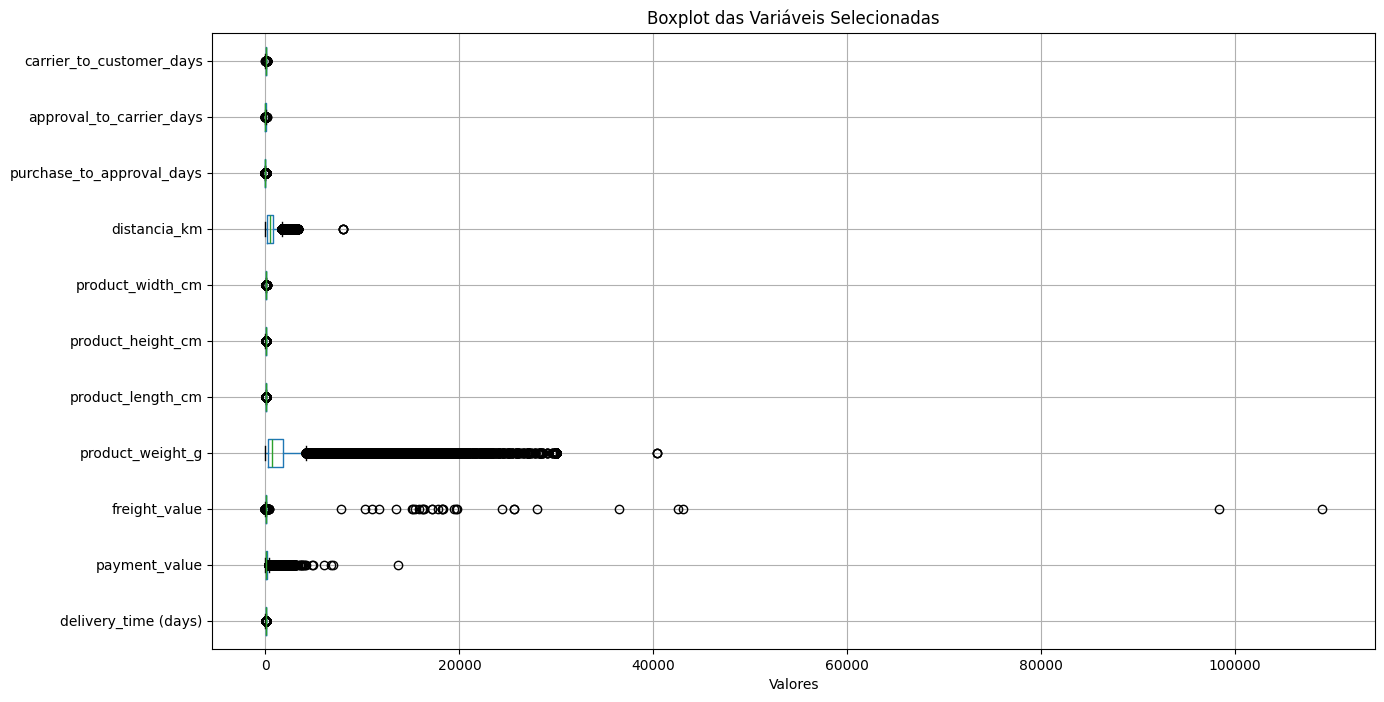

In [50]:
columns_to_plot = [
    'delivery_time (days)', 'payment_value', 'freight_value', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'distancia_km', 'purchase_to_approval_days', 'approval_to_carrier_days', 'carrier_to_customer_days'
]

# Criar o boxplot para todas as colunas
df_treino[columns_to_plot].boxplot(figsize=(15, 8), vert=False)
plt.title('Boxplot das Variáveis Selecionadas')
plt.xlabel('Valores')
plt.show()

In [54]:
df_dis = df_out
Q1 = df_dis['delivery_time (days)'].quantile(0.25)
Q3 = df_dis['delivery_time (days)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar os dados para remover outliers
df_dis = df_dis[(df_dis['delivery_time (days)'] >= lower_bound) & (df_dis['delivery_time (days)'] <= upper_bound)]
display(df_dis)
df_out.to_csv('treino_distancia.csv', index=False)


,order_id,delivery_time (days),geolocation_city_c,geolocation_state_c,payment_value,freight_value,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_city_s,geolocation_state_s,product_volume,distancia_km,purchase_to_approval_days,approval_to_carrier_days,carrier_to_customer_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.61,campos dos goytacazes,RJ,72.19,13.29,volta redonda,SP,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,RJ,3528.0,301.005664,0.032326,6.367141,1.214954
1,00018f77f2f0320c557190d7a144bdd3,16.22,santa fe do sul,SP,259.83,19.93,sao paulo,SP,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP,60000.0,589.274140,0.008414,8.145683,8.062083
2,000229ec398224ef6ca0657da4fc703e,7.95,pará de minas,MG,216.87,17.87,borda da mata,MG,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG,14157.0,312.495046,0.010405,1.908542,6.029491
3,00042b26cf59d7ce69dfabb4e55b4fd9,25.11,varzea paulista,SP,218.04,18.14,loanda,PR,ferramentas_jardim,3750.0,35.0,40.0,30.0,loanda,PR,42000.0,646.221788,0.008588,11.816620,13.289144
4,00048cc3ae777c65dbb7d2a0634bc1ea,6.67,uberaba,MG,34.59,12.69,ribeirao preto,SP,utilidades_domesticas,450.0,24.0,8.0,15.0,ribeirao preto,SP,2880.0,161.597746,1.258947,0.298935,5.110185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68318,fffa82886406ccf10c7b4e35c4ff2788,21.08,tenente ananias,RN,273.92,44.02,pirituba,SP,esporte_lazer,2700.0,60.0,15.0,15.0,sao paulo,SP,13500.0,2102.634123,0.041632,2.056898,18.977894
68320,fffb2ef8874127f75b52b643880fd7e0,17.06,cordeiro,RJ,39.96,22.06,brusque,SC,cama_mesa_banho,200.0,25.0,5.0,18.0,brusque,SC,2250.0,876.529078,3.563704,0.419282,13.072442
68321,fffb9224b6fc7c43ebb0904318b10b5f,21.12,serra talhada,PE,356.76,34.19,sao goncalo,RJ,relogios_presentes,350.0,16.0,14.0,11.0,sao goncalo,RJ,2464.0,1725.685456,0.420116,13.691597,7.006829
68322,fffce4705a9662cd70adb13d4a31832d,4.80,sao paulo,SP,116.85,16.95,curitiba,PR,esporte_lazer,967.0,21.0,24.0,19.0,curitiba,PR,9576.0,338.827218,1.004502,1.915845,1.881343
